In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# display settings
pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")

In [2]:
vitals = pd.read_csv("../data/raw/vital_signs.csv")
vitals.head()

,Patient ID,Heart Rate,Respiratory Rate,Timestamp,Body Temperature,Oxygen Saturation,Systolic Blood Pressure,Diastolic Blood Pressure,Age,Gender,Weight (kg),Height (m),Derived_HRV,Derived_Pulse_Pressure,Derived_BMI,Derived_MAP,Risk Category
0,1,60,12,2024-07-19 21:53:45.729841,36.861707,95.702046,124,86,37,Female,91.541618,1.679351,0.121033,38,32.459031,98.666667,High Risk
1,2,63,18,2024-07-19 21:52:45.729841,36.511633,96.689413,126,84,77,Male,50.704921,1.992546,0.117062,42,12.771246,98.000000,High Risk
2,3,63,15,2024-07-19 21:51:45.729841,37.052049,98.508265,131,78,68,Female,90.316760,1.770228,0.053200,53,28.821069,95.666667,Low Risk
3,4,99,16,2024-07-19 21:50:45.729841,36.654748,95.011801,118,72,41,Female,96.006188,1.833629,0.064475,46,28.554611,87.333333,High Risk
4,5,69,16,2024-07-19 21:49:45.729841,36.975098,98.623792,138,76,25,Female,56.020006,1.866419,0.118484,62,16.081438,96.666667,High Risk


In [3]:
vitals.columns

Index(['Patient ID', 'Heart Rate', 'Respiratory Rate', 'Timestamp',
       'Body Temperature', 'Oxygen Saturation', 'Systolic Blood Pressure',
       'Diastolic Blood Pressure', 'Age', 'Gender', 'Weight (kg)',
       'Height (m)', 'Derived_HRV', 'Derived_Pulse_Pressure', 'Derived_BMI',
       'Derived_MAP', 'Risk Category'],
      dtype='str')

In [4]:
vitals.head()

,Patient ID,Heart Rate,Respiratory Rate,Timestamp,Body Temperature,Oxygen Saturation,Systolic Blood Pressure,Diastolic Blood Pressure,Age,Gender,Weight (kg),Height (m),Derived_HRV,Derived_Pulse_Pressure,Derived_BMI,Derived_MAP,Risk Category
0,1,60,12,2024-07-19 21:53:45.729841,36.861707,95.702046,124,86,37,Female,91.541618,1.679351,0.121033,38,32.459031,98.666667,High Risk
1,2,63,18,2024-07-19 21:52:45.729841,36.511633,96.689413,126,84,77,Male,50.704921,1.992546,0.117062,42,12.771246,98.000000,High Risk
2,3,63,15,2024-07-19 21:51:45.729841,37.052049,98.508265,131,78,68,Female,90.316760,1.770228,0.053200,53,28.821069,95.666667,Low Risk
3,4,99,16,2024-07-19 21:50:45.729841,36.654748,95.011801,118,72,41,Female,96.006188,1.833629,0.064475,46,28.554611,87.333333,High Risk
4,5,69,16,2024-07-19 21:49:45.729841,36.975098,98.623792,138,76,25,Female,56.020006,1.866419,0.118484,62,16.081438,96.666667,High Risk


In [5]:
vitals.describe(include='all')

,Patient ID,Heart Rate,Respiratory Rate,Timestamp,Body Temperature,Oxygen Saturation,Systolic Blood Pressure,Diastolic Blood Pressure,Age,Gender,Weight (kg),Height (m),Derived_HRV,Derived_Pulse_Pressure,Derived_BMI,Derived_MAP,Risk Category
count,200020.000000,200020.000000,200020.000000,200020,200020.000000,200020.000000,200020.000000,200020.000000,200020.000000,200020,200020.000000,200020.000000,200020.000000,200020.000000,200020.000000,200020.000000,200020
unique,NaN,NaN,NaN,200020,NaN,NaN,NaN,NaN,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,2
top,NaN,NaN,NaN,2024-07-19 21:53:45.729841,NaN,NaN,NaN,NaN,NaN,Female,NaN,NaN,NaN,NaN,NaN,NaN,High Risk
freq,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,100117,NaN,NaN,NaN,NaN,NaN,NaN,105115
mean,100010.500000,79.533747,15.489451,NaN,36.748353,97.504372,124.437971,79.499625,53.446275,NaN,74.996419,1.750031,0.099970,44.938346,25.003625,94.479074,NaN
std,57740.944759,11.552894,2.294472,NaN,0.433290,1.442598,8.656946,5.757248,20.786802,NaN,14.471502,0.144554,0.028861,10.404945,6.447143,4.797891,NaN
min,1.000000,60.000000,12.000000,NaN,36.000004,95.000007,110.000000,70.000000,18.000000,NaN,50.000156,1.500001,0.050000,21.000000,12.505974,83.333333,NaN
25%,50005.750000,70.000000,13.000000,NaN,36.372613,96.256859,117.000000,75.000000,35.000000,NaN,62.423615,1.624777,0.074955,37.000000,20.134367,91.000000,NaN
50%,100010.500000,80.000000,15.000000,NaN,36.747741,97.509629,124.000000,79.000000,53.000000,NaN,74.977169,1.750478,0.099988,45.000000,24.320776,94.333333,NaN
75%,150015.250000,90.000000,17.000000,NaN,37.123003,98.755722,132.000000,84.000000,71.000000,NaN,87.539510,1.875310,0.124917,53.000000,29.187169,98.000000,NaN


Step 2 — Create CLEAN subset

In [29]:
vitals_sample = vitals.sample(n=2000, random_state=42).copy()
cols = [
    'Heart Rate', 'Respiratory Rate', 'Body Temperature', 'Oxygen Saturation',
    'Systolic Blood Pressure', 'Diastolic Blood Pressure', 'Age',
    'Weight (kg)', 'Height (m)'
]

for col in cols:
    vitals_sample[col] = pd.to_numeric(vitals_sample[col], errors='coerce')

In [30]:
import numpy as np

rand = np.random.rand(len(vitals_sample))

vitals_sample['Condition'] = 'Normal'
vitals_sample.loc[rand < 0.15, 'Condition'] = 'Moderate'
vitals_sample.loc[rand < 0.05, 'Condition'] = 'Critical'

In [31]:
mask_mod = vitals_sample['Condition'] == 'Moderate'
mask_crit = vitals_sample['Condition'] == 'Critical'

In [32]:
def assign_values(df, mask, col, low, high):
    df.loc[mask, col] = pd.Series(
        np.random.uniform(low, high, mask.sum()),
        index=df.loc[mask].index
    )

In [34]:
for col in cols:
    vitals_sample[col] = vitals_sample[col].astype(float)

In [35]:
assign_values(vitals_sample, mask_mod, 'Heart Rate', 100, 120)
assign_values(vitals_sample, mask_crit, 'Heart Rate', 120, 160)

In [36]:
assign_values(vitals_sample, mask_mod, 'Respiratory Rate', 18, 22)
assign_values(vitals_sample, mask_crit, 'Respiratory Rate', 22, 30)

In [37]:
assign_values(vitals_sample, mask_mod, 'Body Temperature', 37.5, 38.5)
assign_values(vitals_sample, mask_crit, 'Body Temperature', 38.5, 41)

In [38]:
assign_values(vitals_sample, mask_mod, 'Oxygen Saturation', 90, 94)
assign_values(vitals_sample, mask_crit, 'Oxygen Saturation', 80, 90)

In [39]:
assign_values(vitals_sample, mask_mod, 'Systolic Blood Pressure', 140, 160)
assign_values(vitals_sample, mask_crit, 'Systolic Blood Pressure', 160, 200)

In [40]:
assign_values(vitals_sample, mask_mod, 'Diastolic Blood Pressure', 90, 100)
assign_values(vitals_sample, mask_crit, 'Diastolic Blood Pressure', 100, 130)

In [41]:
def calculate_risk(row):
    score = 0

    if row['Heart Rate'] > 120: score += 2
    elif row['Heart Rate'] > 100: score += 1

    if row['Oxygen Saturation'] < 90: score += 2
    elif row['Oxygen Saturation'] < 95: score += 1

    if row['Body Temperature'] > 39: score += 2
    elif row['Body Temperature'] > 37.5: score += 1

    if row['Systolic Blood Pressure'] > 160: score += 2
    elif row['Systolic Blood Pressure'] > 140: score += 1

    if score >= 5:
        return 'High Risk'
    elif score >= 3:
        return 'Moderate Risk'
    else:
        return 'Low Risk'

In [42]:
vitals_sample['Risk Category'] = vitals_sample.apply(calculate_risk, axis=1)

In [43]:
vitals_sample['Risk Category'].value_counts()

Risk Category
Low Risk         1696
Moderate Risk     207
High Risk          97
Name: count, dtype: int64

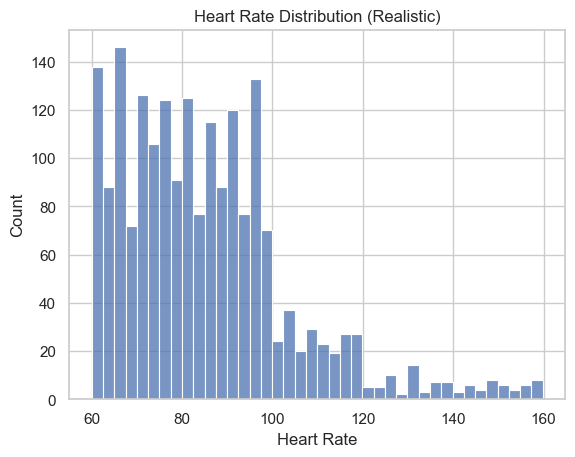

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(vitals_sample['Heart Rate'], bins=40)
plt.title("Heart Rate Distribution (Realistic)")
plt.show()

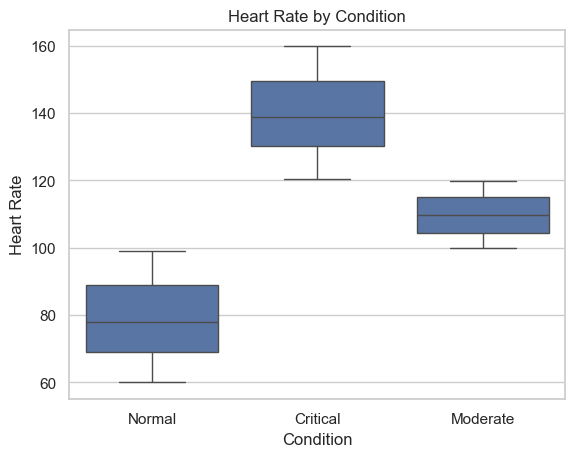

In [45]:
sns.boxplot(x='Condition', y='Heart Rate', data=vitals_sample)
plt.title("Heart Rate by Condition")
plt.show()

CHECK NEW DATASET FOR HUMAN VITALS

In [46]:
vitals_sample.shape
vitals_sample.info()
vitals_sample.head()

<class 'pandas.DataFrame'>
Index: 2000 entries, 79154 to 62248
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Patient ID                2000 non-null   int64  
 1   Heart Rate                2000 non-null   float64
 2   Respiratory Rate          2000 non-null   float64
 3   Timestamp                 2000 non-null   str    
 4   Body Temperature          2000 non-null   float64
 5   Oxygen Saturation         2000 non-null   float64
 6   Systolic Blood Pressure   2000 non-null   float64
 7   Diastolic Blood Pressure  2000 non-null   float64
 8   Age                       2000 non-null   float64
 9   Gender                    2000 non-null   str    
 10  Weight (kg)               2000 non-null   float64
 11  Height (m)                2000 non-null   float64
 12  Derived_HRV               2000 non-null   float64
 13  Derived_Pulse_Pressure    2000 non-null   int64  
 14  Derived_BMI        

,Patient ID,Heart Rate,Respiratory Rate,Timestamp,Body Temperature,Oxygen Saturation,Systolic Blood Pressure,Diastolic Blood Pressure,Age,Gender,Weight (kg),Height (m),Derived_HRV,Derived_Pulse_Pressure,Derived_BMI,Derived_MAP,Risk Category,Condition
79154,79155,95.0,12.0,2024-05-25 22:39:45.931007,37.300428,95.072205,134.0,78.0,28.0,Female,58.227060,1.600762,0.149623,56,22.723303,96.666667,Low Risk,Normal
160758,160759,82.0,13.0,2024-03-30 06:35:46.142927,36.101797,97.354042,123.0,70.0,39.0,Female,88.641106,1.756231,0.090224,53,28.739027,87.666667,Low Risk,Normal
101535,101536,87.0,12.0,2024-05-10 09:38:45.992895,36.280715,96.441567,112.0,78.0,47.0,Male,70.523728,1.941764,0.077123,34,18.704338,89.333333,Low Risk,Normal
57250,57251,74.0,18.0,2024-06-10 03:43:45.873871,37.200086,95.634409,135.0,86.0,82.0,Male,86.565032,1.549998,0.053761,49,36.031308,102.333333,Low Risk,Normal
70287,70288,82.0,19.0,2024-06-01 02:26:45.906877,36.257703,96.895731,133.0,74.0,76.0,Male,89.580576,1.884968,0.116677,59,25.211921,93.666667,Low Risk,Normal


2. Missing values (CRITICAL)

In [47]:
vitals_sample.isnull().sum()

Patient ID                  0
Heart Rate                  0
Respiratory Rate            0
Timestamp                   0
Body Temperature            0
Oxygen Saturation           0
Systolic Blood Pressure     0
Diastolic Blood Pressure    0
Age                         0
Gender                      0
Weight (kg)                 0
Height (m)                  0
Derived_HRV                 0
Derived_Pulse_Pressure      0
Derived_BMI                 0
Derived_MAP                 0
Risk Category               0
Condition                   0
dtype: int64

3. Summary statistics (range validation)

In [48]:
vitals_sample.describe()

,Patient ID,Heart Rate,Respiratory Rate,Body Temperature,Oxygen Saturation,Systolic Blood Pressure,Diastolic Blood Pressure,Age,Weight (kg),Height (m),Derived_HRV,Derived_Pulse_Pressure,Derived_BMI,Derived_MAP
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,101474.173000,85.083117,16.518524,37.038015,96.273568,129.529094,82.829831,52.636000,74.952119,1.758681,0.100447,44.883500,24.734019,94.444167
std,57105.398054,19.057928,3.357758,0.855096,3.356630,15.933340,10.381306,20.446235,14.413733,0.144033,0.028544,10.164427,6.340613,4.837564
min,102.000000,60.000000,12.000000,36.000845,80.120092,110.000000,70.000000,18.000000,50.024178,1.500025,0.050021,21.000000,12.727400,83.333333
25%,53741.250000,71.000000,14.000000,36.460566,95.511015,118.000000,75.000000,35.000000,62.529727,1.633373,0.076360,37.000000,20.106862,91.000000
50%,100462.500000,82.000000,16.000000,36.891569,96.916164,127.000000,81.000000,52.000000,74.684081,1.767518,0.100298,45.000000,23.965300,94.666667
75%,152564.500000,95.000000,18.575683,37.323245,98.429235,136.000000,87.000000,70.000000,87.745674,1.882133,0.124513,52.000000,28.811438,98.000000
max,199997.000000,159.820809,29.887693,40.989641,99.999441,199.375253,129.801696,89.000000,99.973252,1.999601,0.149963,69.000000,44.376487,105.666667


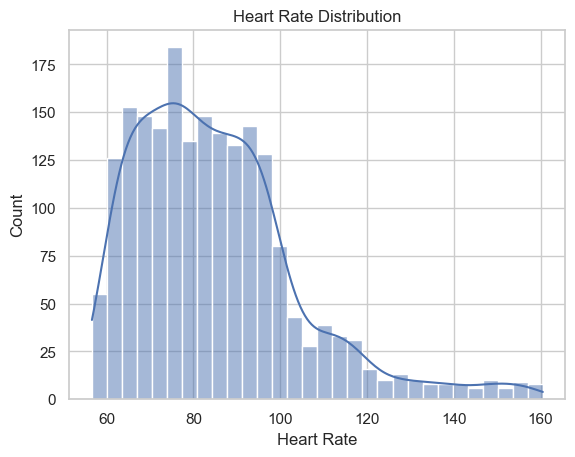

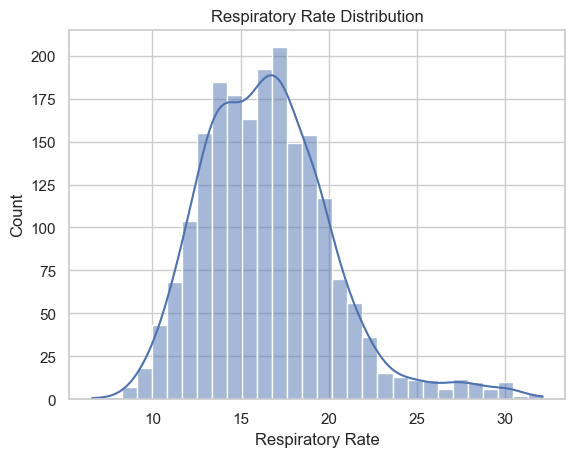

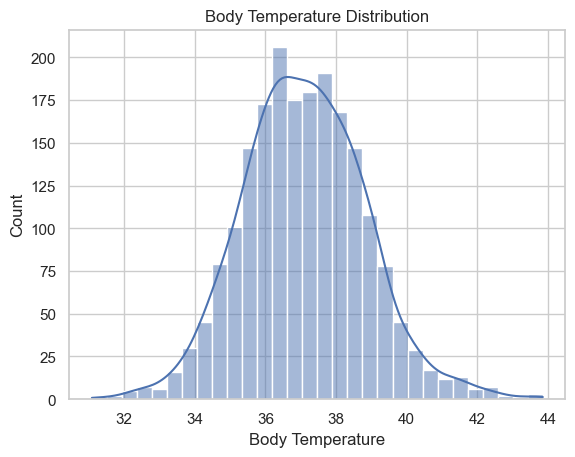

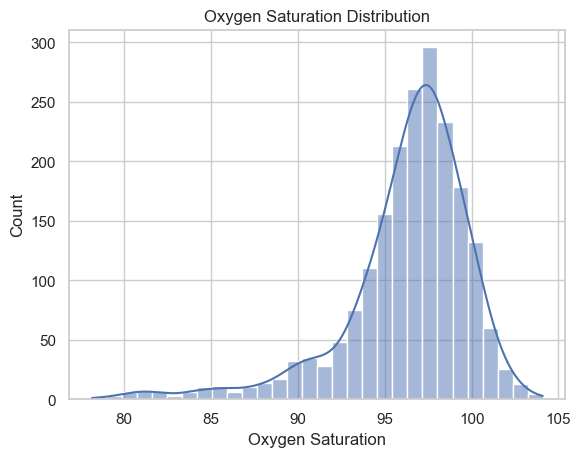

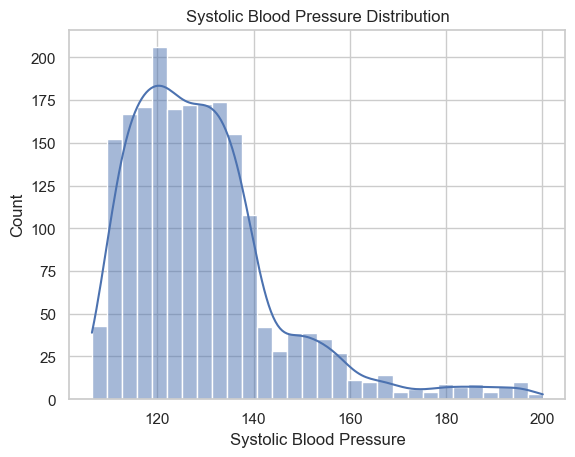

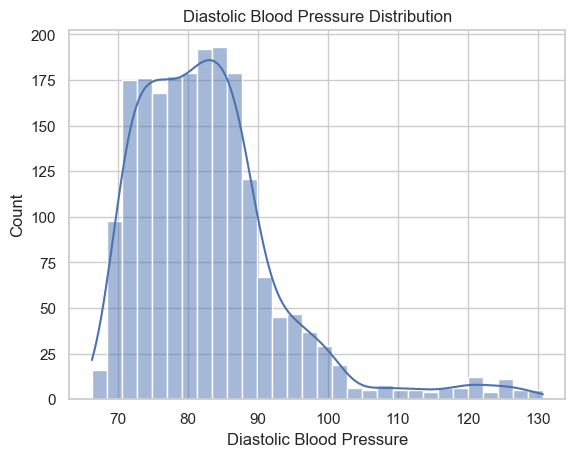

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

cols = ['Heart Rate','Respiratory Rate','Body Temperature',
        'Oxygen Saturation','Systolic Blood Pressure','Diastolic Blood Pressure']

for col in cols:
    plt.figure()
    sns.histplot(vitals_sample[col], bins=30, kde=True)
    plt.title(f"{col} Distribution")
    plt.show()

In [50]:
for col in cols:
    vitals_sample[col] += np.random.normal(0, 1.5, len(vitals_sample))

In [52]:
vitals_sample['Heart Rate'] = vitals_sample['Heart Rate'].clip(40, 180)
vitals_sample['Respiratory Rate'] = vitals_sample['Respiratory Rate'].clip(8, 35)
vitals_sample['Body Temperature'] = vitals_sample['Body Temperature'].clip(34, 42)
vitals_sample['Oxygen Saturation'] = vitals_sample['Oxygen Saturation'].clip(80, 100)
vitals_sample['Systolic Blood Pressure'] = vitals_sample['Systolic Blood Pressure'].clip(90, 200)
vitals_sample['Diastolic Blood Pressure'] = vitals_sample['Diastolic Blood Pressure'].clip(60, 130)

In [53]:
# NORMAL patients
mask = vitals_sample['Condition'] == 'Normal'
vitals_sample.loc[mask, 'Heart Rate'] = vitals_sample.loc[mask, 'Heart Rate'].clip(60, 100)
vitals_sample.loc[mask, 'Body Temperature'] = vitals_sample.loc[mask, 'Body Temperature'].clip(36, 37.5)

# MODERATE
mask = vitals_sample['Condition'] == 'Moderate'
vitals_sample.loc[mask, 'Heart Rate'] = vitals_sample.loc[mask, 'Heart Rate'].clip(90, 120)

# CRITICAL
mask = vitals_sample['Condition'] == 'Critical'
vitals_sample.loc[mask, 'Heart Rate'] = vitals_sample.loc[mask, 'Heart Rate'].clip(110, 180)

In [55]:
vitals_sample['Derived_BMI'] = vitals_sample['Weight (kg)'] / (vitals_sample['Height (m)'] ** 2)
vitals_sample['Derived_MAP'] = (vitals_sample['Systolic Blood Pressure'] + 2 * vitals_sample['Diastolic Blood Pressure']) / 3
vitals_sample['Derived_Pulse_Pressure'] = vitals_sample['Systolic Blood Pressure'] - vitals_sample['Diastolic Blood Pressure']

In [56]:
vitals_sample.describe()

,Patient ID,Heart Rate,Respiratory Rate,Body Temperature,Oxygen Saturation,Systolic Blood Pressure,Diastolic Blood Pressure,Age,Weight (kg),Height (m),Derived_HRV,Derived_Pulse_Pressure,Derived_BMI,Derived_MAP
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,101474.173000,85.110684,16.529393,37.053438,96.215560,129.536706,82.819530,52.636000,74.952119,1.758681,0.100447,46.717176,24.734019,98.391922
std,57105.398054,19.055392,3.719528,1.108073,3.518074,16.027531,10.462393,20.446235,14.413733,0.144033,0.028544,11.510779,6.340613,11.364756
min,102.000000,60.000000,8.000000,34.000000,80.000000,106.357875,66.295669,18.000000,50.024178,1.500025,0.050021,18.440013,12.727400,82.384792
25%,53741.250000,70.832129,13.832910,36.000000,95.015985,118.229951,75.272496,35.000000,62.529727,1.633373,0.076360,38.519892,20.106862,91.525615
50%,100462.500000,81.983730,16.290035,37.053619,96.979911,126.893524,81.436309,52.000000,74.684081,1.767518,0.100298,46.981812,23.965300,95.659886
75%,152564.500000,94.570494,18.615316,37.500000,98.580919,136.169082,87.118548,70.000000,87.745674,1.882133,0.124513,54.432164,28.811438,100.955853
max,199997.000000,160.520288,32.129302,42.000000,100.000000,200.000000,130.000000,89.000000,99.973252,1.999601,0.149963,97.516731,44.376487,149.139656


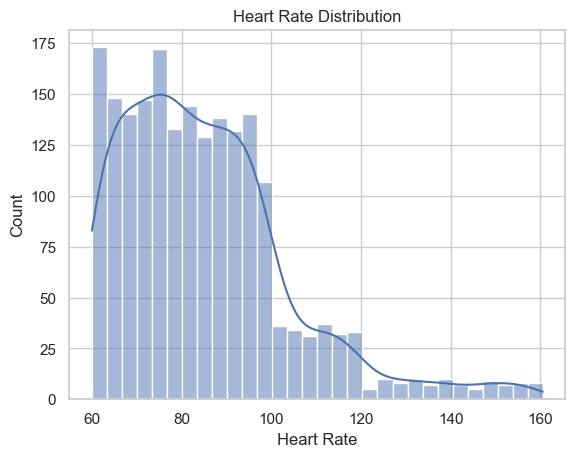

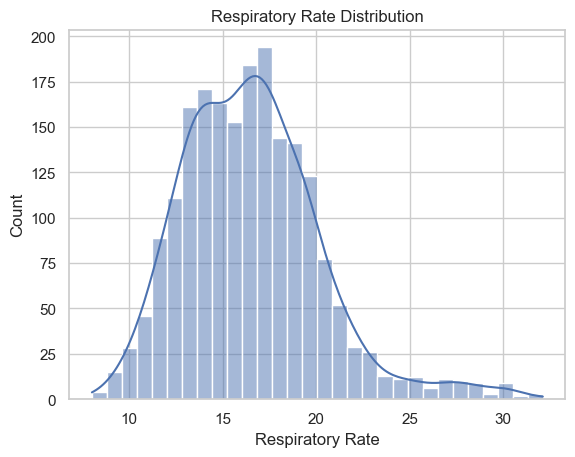

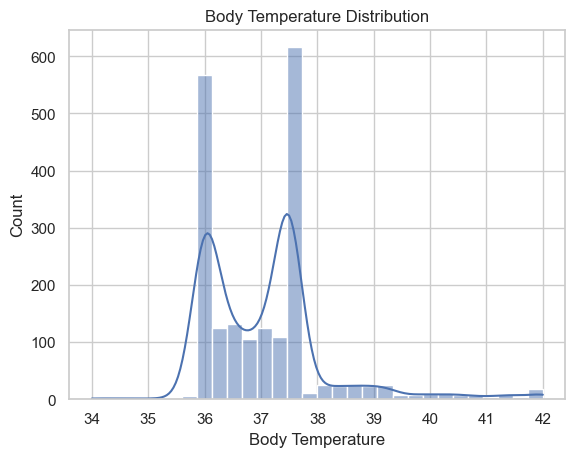

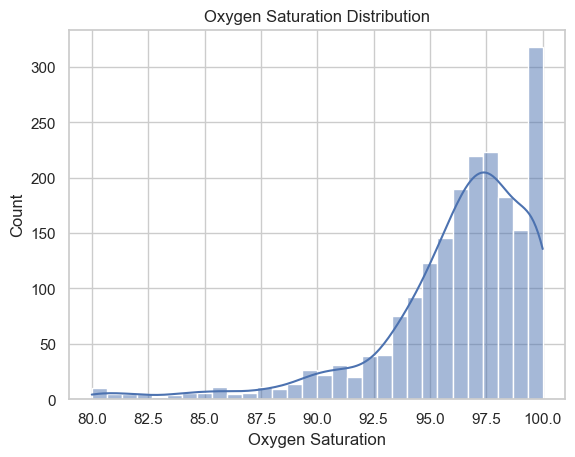

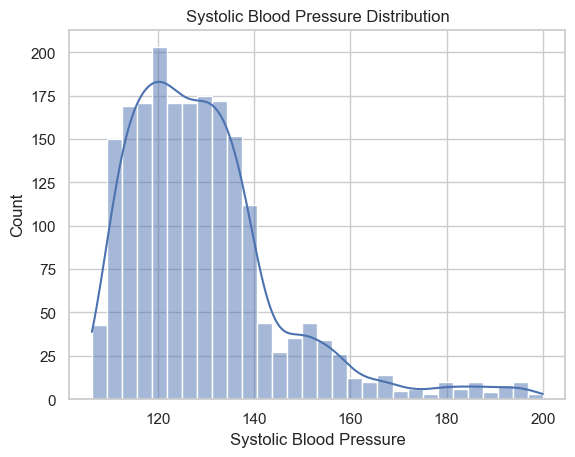

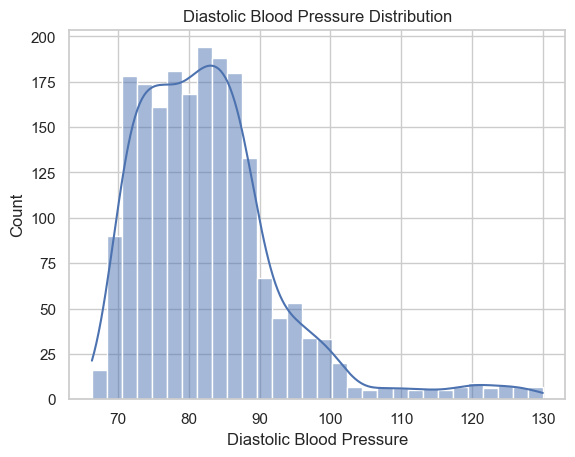

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

cols = ['Heart Rate','Respiratory Rate','Body Temperature',
        'Oxygen Saturation','Systolic Blood Pressure','Diastolic Blood Pressure']

for col in cols:
    plt.figure()
    sns.histplot(vitals_sample[col], bins=30, kde=True)
    plt.title(f"{col} Distribution")
    plt.show()

In [58]:
vitals_sample.dtypes

Patient ID                    int64
Heart Rate                  float64
Respiratory Rate            float64
Timestamp                       str
Body Temperature            float64
Oxygen Saturation           float64
Systolic Blood Pressure     float64
Diastolic Blood Pressure    float64
Age                         float64
Gender                          str
Weight (kg)                 float64
Height (m)                  float64
Derived_HRV                 float64
Derived_Pulse_Pressure      float64
Derived_BMI                 float64
Derived_MAP                 float64
Risk Category                   str
Condition                       str
dtype: object

In [59]:
vitals_sample = vitals_sample[
    (vitals_sample['Heart Rate'].between(40, 180)) &
    (vitals_sample['Respiratory Rate'].between(8, 35)) &
    (vitals_sample['Body Temperature'].between(34, 42)) &
    (vitals_sample['Oxygen Saturation'].between(80, 100)) &
    (vitals_sample['Systolic Blood Pressure'].between(90, 200)) &
    (vitals_sample['Diastolic Blood Pressure'].between(60, 130))
    ]

In [60]:
vitals_sample = vitals_sample[
    vitals_sample['Diastolic Blood Pressure'] < vitals_sample['Systolic Blood Pressure']
    ]

In [61]:
vitals_sample['Derived_BMI'] = vitals_sample['Weight (kg)'] / (vitals_sample['Height (m)'] ** 2)

vitals_sample['Derived_MAP'] = (
                                       vitals_sample['Systolic Blood Pressure'] +
                                       2 * vitals_sample['Diastolic Blood Pressure']
                               ) / 3

vitals_sample['Derived_Pulse_Pressure'] = (
        vitals_sample['Systolic Blood Pressure'] -
        vitals_sample['Diastolic Blood Pressure']
)

In [62]:
vitals_sample.describe().T

,count,mean,std,min,25%,50%,75%,max
Patient ID,2000.0,101474.173000,57105.398054,102.000000,53741.250000,100462.500000,152564.500000,199997.000000
Heart Rate,2000.0,85.110684,19.055392,60.000000,70.832129,81.983730,94.570494,160.520288
Respiratory Rate,2000.0,16.529393,3.719528,8.000000,13.832910,16.290035,18.615316,32.129302
Body Temperature,2000.0,37.053438,1.108073,34.000000,36.000000,37.053619,37.500000,42.000000
Oxygen Saturation,2000.0,96.215560,3.518074,80.000000,95.015985,96.979911,98.580919,100.000000
Systolic Blood Pressure,2000.0,129.536706,16.027531,106.357875,118.229951,126.893524,136.169082,200.000000
Diastolic Blood Pressure,2000.0,82.819530,10.462393,66.295669,75.272496,81.436309,87.118548,130.000000
Age,2000.0,52.636000,20.446235,18.000000,35.000000,52.000000,70.000000,89.000000
Weight (kg),2000.0,74.952119,14.413733,50.024178,62.529727,74.684081,87.745674,99.973252
Height (m),2000.0,1.758681,0.144033,1.500025,1.633373,1.767518,1.882133,1.999601


In [64]:
vitals_sample.to_csv("../data/processed/vitals_final.csv", index=False)